
# Model Training (Single-Head): AlexNet, GFNet, ViT

This notebook trains and saves **three single-head architectures** on the same multispectral dataset:

1. AlexNet-based CNN
2. Global Filter Network (GFNet)
3. Vision Transformer (ViT, U-Net style skip flow)

It also reports classification performance side-by-side so the best saved model can be reused later for uncertainty analysis without retraining.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    f1_score,
    log_loss,
)

sns.set_style("whitegrid")
print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [5]:
# -----------------------------
# Configuration
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path("/content/drive/My Drive/m_p/")
DATA_DIR = PROJECT_ROOT / "data" / "multispectral"
MODEL_DIR = PROJECT_ROOT / "saved_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = MODEL_DIR / "training_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = DATA_DIR / "data.csv"
LABEL_FILE = DATA_DIR / "ref.csv"

# Dataset geometry for current 6-band data
H, W, B = 330, 307, 6
PATCH_SIZE = 9
INNER_PATCH = 3  # used by GFNet/ViT tokenization
TRAIN_PERCENT = 0.75
VAL_SPLIT_FROM_TRAIN = 0.20

BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 3e-4
DROPOUT_RATE = 0.25

# Legacy architecture configs (aligned to original single-head notebooks)
CAPACITY_PRESET = "legacy_arch"
ALEXNET_CFG = {
    "conv_filters": [96, 256, 384, 384, 256],
    "dense_units": [4096, 1024, 256, 32],
}
GFNET_CFG = {
    "hidden_dim": 512,
    "num_blocks": 5,
    "mlp_ratio": 4,
}
VIT_CFG = {
    "projection_dim": 256,
    "num_heads": 4,
    "transformer_layers": 12,
    "mlp_multiplier": 2,
    "head_units": [512, 256, 128, 64],
}

# Deterministic fallback if Colab runs out of memory
GFNET_FALLBACK_CFG = {
    "hidden_dim": 384,
    "num_blocks": 4,
    "mlp_ratio": 4,
}
VIT_FALLBACK_CFG = {
    "projection_dim": 192,
    "num_heads": 4,
    "transformer_layers": 8,
    "mlp_multiplier": 2,
    "head_units": [384, 192, 96, 64],
}

# Keep training policy unchanged
TRAIN_CFG = {
    "label_smoothing": 0.05,
    "weight_decay": 1e-4,
    "clipnorm": 1.0,
    "cosine_alpha": 0.05,
}

print("Data file:", DATA_FILE)
print("Label file:", LABEL_FILE)
print("Model save dir:", MODEL_DIR)
print("Plot save dir:", PLOT_DIR)
print("Architecture preset:", CAPACITY_PRESET)

# AlexNet legacy-recipe controls (for uncertainty recovery)
ALEXNET_LEGACY_SPLIT_SEED = 10
ALEXNET_LEGACY_TRAIN_PERCENT = 0.75
ALEXNET_LR_START = 0.01
ALEXNET_LR_MAX = 0.02
ALEXNET_LR_MIN = 0.005


Data file: /content/drive/My Drive/m_p/data/multispectral/data.csv
Label file: /content/drive/My Drive/m_p/data/multispectral/ref.csv
Model save dir: /content/drive/My Drive/m_p/saved_models
Plot save dir: /content/drive/My Drive/m_p/saved_models/training_plots
Architecture preset: legacy_arch


In [6]:

# -----------------------------
# Data loading and patch extraction
# -----------------------------
def load_multispectral_6band(data_path: Path, label_path: Path, height: int, width: int, bands: int):
    x = pd.read_csv(data_path).to_numpy(dtype=np.float32).reshape(height, width, bands)
    y = pd.read_csv(label_path).to_numpy(dtype=np.int32).reshape(height, width)

    # Band-wise min-max normalization to [0, 1]
    x_norm = np.empty_like(x, dtype=np.float32)
    for b in range(bands):
        band = x[:, :, b]
        band_min = np.min(band)
        band_max = np.max(band)
        denom = max(band_max - band_min, 1e-8)
        x_norm[:, :, b] = (band - band_min) / denom

    return x_norm, y


def extract_labeled_patches(x, y, patch_size=9):
    pad = patch_size // 2
    x_pad = np.pad(x, ((pad, pad), (pad, pad), (0, 0)), mode="edge")

    coords = np.argwhere(y > 0)
    patches = np.empty((coords.shape[0], patch_size, patch_size, x.shape[-1]), dtype=np.float32)
    labels = np.empty((coords.shape[0],), dtype=np.int32)

    for i, (r, c) in enumerate(coords):
        patches[i] = x_pad[r:r + patch_size, c:c + patch_size, :]
        labels[i] = int(y[r, c]) - 1  # convert class IDs to 0..C-1

    return patches, labels, coords


x_img, y_img = load_multispectral_6band(DATA_FILE, LABEL_FILE, H, W, B)
X, y, coords = extract_labeled_patches(x_img, y_img, PATCH_SIZE)

num_classes = int(np.unique(y).size)
input_shape = (PATCH_SIZE, PATCH_SIZE, B)

print("x_img:", x_img.shape, "y_img:", y_img.shape)
print("Labeled samples:", X.shape[0])
print("Patch tensor:", X.shape)
print("Num classes:", num_classes)


x_img: (330, 307, 6) y_img: (330, 307)
Labeled samples: 17239
Patch tensor: (17239, 9, 9, 6)
Num classes: 7


In [7]:

# -----------------------------
# Train/val/test split
# -----------------------------
x_train_full, x_test, y_train_full, y_test = train_test_split(
    X,
    y,
    train_size=TRAIN_PERCENT,
    random_state=SEED,
    stratify=y,
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=VAL_SPLIT_FROM_TRAIN,
    random_state=SEED,
    stratify=y_train_full,
)

y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print("Train:", x_train.shape, y_train.shape)
print("Val:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)


# AlexNet legacy split (matches old single-head script behavior)
x_train_alex, x_test_alex, y_train_alex, y_test_alex = train_test_split(
    X,
    y,
    train_size=ALEXNET_LEGACY_TRAIN_PERCENT,
    random_state=ALEXNET_LEGACY_SPLIT_SEED,
    stratify=y,
)

y_train_alex_cat = keras.utils.to_categorical(y_train_alex, num_classes)
y_test_alex_cat = keras.utils.to_categorical(y_test_alex, num_classes)

print('AlexNet Train/Test:', x_train_alex.shape, y_train_alex.shape, x_test_alex.shape, y_test_alex.shape)


Train: (10343, 9, 9, 6) (10343,)
Val: (2586, 9, 9, 6) (2586,)
Test: (4310, 9, 9, 6) (4310,)
AlexNet Train/Test: (12929, 9, 9, 6) (12929,) (4310, 9, 9, 6) (4310,)


## Model Definitions

In [8]:
# -----------------------------
# 1) AlexNet-based CNN (single-head, legacy architecture)
# -----------------------------
def build_alexnet(input_shape, num_classes, dropout_rate=0.25, cfg=None):
    cfg = cfg or ALEXNET_CFG

    inputs = keras.Input(shape=input_shape)
    x = inputs

    for i, filters in enumerate(cfg["conv_filters"], start=1):
        x = layers.Conv2D(filters, (3, 3), activation="relu", padding="same", name=f"alex_conv_{i}")(x)

    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding="same", name="alex_pool")(x)

    dense_units = cfg["dense_units"]
    x = layers.Flatten(name="alex_flatten")(x)
    x = layers.Dense(dense_units[0], activation="relu", name="alex_fc1")(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(x)
    x = layers.Dense(dense_units[1], activation="relu", name="alex_fc2")(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_2")(x)
    x = layers.Dense(dense_units[2], activation="relu", name="alex_fc3")(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(x)
    x = layers.Dense(dense_units[3], activation="relu", name="alex_fc4")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="alex_logits")(x)
    return keras.Model(inputs, outputs, name="AlexNet_SingleHead")

In [9]:
# -----------------------------
# 2) Global Filter Network (single-head, legacy architecture)
# -----------------------------
@tf.keras.utils.register_keras_serializable()
class PatchExtractor(layers.Layer):
    def __init__(self, patch_size=3, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        batch = tf.shape(images)[0]
        num_patches = tf.shape(patches)[1] * tf.shape(patches)[2]
        patch_dim = tf.shape(patches)[-1]
        return tf.reshape(patches, [batch, num_patches, patch_dim])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"patch_size": self.patch_size})
        return cfg


@tf.keras.utils.register_keras_serializable()
class PatchPositionEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return cfg


@tf.keras.utils.register_keras_serializable()
class GlobalFilterLayer(layers.Layer):
    def __init__(self, token_side, **kwargs):
        super().__init__(**kwargs)
        self.token_side = token_side

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.w_real = self.add_weight(
            name="w_real",
            shape=(self.token_side, self.token_side, channels),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.w_imag = self.add_weight(
            name="w_imag",
            shape=(self.token_side, self.token_side, channels),
            initializer="zeros",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        batch = tf.shape(x)[0]
        channels = tf.shape(x)[-1]
        x_2d = tf.reshape(x, [batch, self.token_side, self.token_side, channels])
        x_fft = tf.signal.fft2d(tf.cast(x_2d, tf.complex64))
        w_complex = tf.complex(self.w_real, self.w_imag)
        x_filtered = x_fft * w_complex
        x_spatial = tf.math.real(tf.signal.ifft2d(x_filtered))
        return tf.reshape(x_spatial, [batch, self.token_side * self.token_side, channels])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"token_side": self.token_side})
        return cfg


def gf_block(x, token_side, dim, mlp_ratio=4, dropout_rate=0.25, name_prefix="gf"):
    # Legacy block style: one residual add after filter + MLP branch.
    y = layers.LayerNormalization(name=f"{name_prefix}_ln1")(x)
    y = GlobalFilterLayer(token_side, name=f"{name_prefix}_gfilter")(y)
    y = layers.LayerNormalization(name=f"{name_prefix}_ln2")(y)
    y = layers.Dense(dim * mlp_ratio, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp1")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop1")(y)
    y = layers.Dense(dim, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp2")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop2")(y)
    return layers.Add(name=f"{name_prefix}_add")([x, y])


def build_gfnet(
    input_shape,
    num_classes,
    inner_patch=3,
    hidden_dim=512,
    num_blocks=5,
    mlp_ratio=4,
    dropout_rate=0.25,
):
    num_patches = (input_shape[0] // inner_patch) * (input_shape[1] // inner_patch)
    token_side = int(np.sqrt(num_patches))

    inputs = keras.Input(shape=input_shape)
    x = PatchExtractor(inner_patch, name="gf_patch_extractor")(inputs)
    x = PatchPositionEncoder(num_patches, hidden_dim, name="gf_patch_encoder")(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(x)

    for i in range(num_blocks):
        x = gf_block(x, token_side, hidden_dim, mlp_ratio, dropout_rate, name_prefix=f"gf_block_{i+1}")

    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_2")(x)
    x = layers.LayerNormalization(name="gf_final_ln")(x)
    x = layers.GlobalAveragePooling1D(name="gf_gap")(x)
    x = layers.Flatten(name="gf_flatten")(x)
    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="gf_logits")(x)

    return keras.Model(inputs, outputs, name="GFNet_SingleHead")

In [10]:
# -----------------------------
# 3) Vision Transformer (single-head, U-Net style skip flow, legacy architecture)
# -----------------------------
@tf.keras.utils.register_keras_serializable()
class PatchEncoderWithCLS(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches + 1, output_dim=projection_dim)

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, self.projection_dim),
            initializer="zeros",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, patches):
        batch = tf.shape(patches)[0]
        patch_proj = self.projection(patches)
        cls_tokens = tf.repeat(self.cls_token, repeats=batch, axis=0)
        x = tf.concat([cls_tokens, patch_proj], axis=1)
        positions = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        return x + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return cfg


def transformer_block(x, num_heads, projection_dim, mlp_dim, dropout_rate, name_prefix):
    y = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln1")(x)
    y = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim,
        dropout=dropout_rate,
        name=f"{name_prefix}_mha",
    )(y, y)
    x = layers.Add(name=f"{name_prefix}_add1")([y, x])

    y = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln2")(x)
    y = layers.Dense(mlp_dim, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp1")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop1")(y)
    y = layers.Dense(projection_dim, activation=tf.keras.activations.gelu, name=f"{name_prefix}_mlp2")(y)
    y = layers.Dropout(dropout_rate, name=f"{name_prefix}_drop2")(y)
    return layers.Add(name=f"{name_prefix}_add2")([y, x])


def build_vit_unet_singlehead(
    input_shape,
    num_classes,
    inner_patch=3,
    projection_dim=256,
    num_heads=4,
    transformer_layers=12,
    mlp_multiplier=2,
    dropout_rate=0.25,
    head_units=(512, 256, 128, 64),
):
    num_patches = (input_shape[0] // inner_patch) * (input_shape[1] // inner_patch)

    inputs = keras.Input(shape=input_shape)
    x = PatchExtractor(inner_patch, name="vit_patch_extractor")(inputs)
    x = PatchEncoderWithCLS(num_patches, projection_dim, name="vit_patch_encoder")(x)

    block_list = []
    for i in range(transformer_layers):
        x = transformer_block(
            x,
            num_heads=num_heads,
            projection_dim=projection_dim,
            mlp_dim=projection_dim * mlp_multiplier,
            dropout_rate=0.1,
            name_prefix=f"vit_block_{i+1}",
        )

        if i <= transformer_layers // 2:
            block_list.append(x)
        else:
            x = layers.Add(name=f"vit_skip_add_{i+1}")([x, block_list[transformer_layers - i - 1]])

    x = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_1")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="vit_cls_norm")(x)
    cls_token = layers.Lambda(lambda t: t[:, 0, :], name="vit_cls_token")(x)

    y = layers.Dense(head_units[0], activation=tf.keras.activations.gelu, name="vit_head_1")(cls_token)
    y = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_3")(y)
    y = layers.Dense(head_units[1], activation=tf.keras.activations.gelu, name="vit_head_2")(y)
    y = layers.Dense(head_units[2], activation=tf.keras.activations.gelu, name="vit_head_3")(y)
    y = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_5")(y)
    y = layers.Dense(head_units[3], activation=tf.keras.activations.gelu, name="vit_head_4")(y)
    y = layers.Dropout(dropout_rate, name="TRAIN_DROPOUT_6")(y)

    outputs = layers.Dense(num_classes, activation="softmax", name="vit_logits")(y)
    return keras.Model(inputs, outputs, name="ViT_UNet_SingleHead")

## Train, Save, and Evaluate

In [ ]:
# -----------------------------
# Training and evaluation helpers
# -----------------------------
def multiclass_brier_score(y_onehot, y_prob):
    return float(np.mean(np.sum((y_prob - y_onehot) ** 2, axis=1)))


def expected_calibration_error(y_true, y_prob, n_bins=15):
    confidences = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)
    correct = (predictions == y_true).astype(np.float32)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            in_bin = (confidences >= lo) & (confidences <= hi)
        else:
            in_bin = (confidences >= lo) & (confidences < hi)
        prop = np.mean(in_bin)
        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidences[in_bin])
            ece += np.abs(acc_bin - conf_bin) * prop
    return float(ece)


def make_optimizer(num_train_samples):
    steps_per_epoch = int(np.ceil(num_train_samples / BATCH_SIZE))
    decay_steps = max(1, steps_per_epoch * EPOCHS)
    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE,
        decay_steps=decay_steps,
        alpha=TRAIN_CFG["cosine_alpha"],
    )
    optimizer = keras.optimizers.AdamW(
        learning_rate=lr_schedule,
        weight_decay=TRAIN_CFG["weight_decay"],
        clipnorm=TRAIN_CFG["clipnorm"],
    )
    return optimizer


def _alexnet_legacy_lr(epoch):
    # old-script cosine style between [ALEXNET_LR_MIN, ALEXNET_LR_MAX]
    if EPOCHS <= 1:
        return ALEXNET_LR_START
    phase = np.pi * epoch / (EPOCHS - 1)
    cosine_decay = 0.5 * (1.0 + np.cos(phase))
    return float((ALEXNET_LR_MAX - ALEXNET_LR_MIN) * cosine_decay + ALEXNET_LR_MIN)


def train_save_evaluate(model_name, model_builder, capacity_tag="max"):
    tf.keras.backend.clear_session()

    model = model_builder()
    best_path = MODEL_DIR / f"{model_name}_best.keras"
    final_path = MODEL_DIR / f"{model_name}_final.keras"

    # AlexNet-specific legacy recipe for uncertainty recovery
    if model_name == "AlexNet_CNN":
        model.compile(
            optimizer=keras.optimizers.Adagrad(learning_rate=ALEXNET_LR_START),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )

        callbacks = [
            keras.callbacks.ModelCheckpoint(
                filepath=str(best_path),
                monitor="val_accuracy",
                mode="max",
                save_best_only=True,
                verbose=1,
            ),
            keras.callbacks.LearningRateScheduler(_alexnet_legacy_lr, verbose=0),
        ]

        x_tr, y_tr = x_train_alex, y_train_alex
        x_va, y_va = x_test_alex, y_test_alex
        x_te, y_te, y_te_cat = x_test_alex, y_test_alex, y_test_alex_cat
        x_eval_for_metrics, y_eval_for_metrics, y_eval_for_metrics_cat = x_test_alex, y_test_alex, y_test_alex_cat
        fit_shuffle = False

    else:
        # Keep GFNet/ViT path unchanged
        model.compile(
            optimizer=make_optimizer(len(x_train)),
            loss=keras.losses.CategoricalCrossentropy(label_smoothing=TRAIN_CFG["label_smoothing"]),
            metrics=["accuracy"],
        )

        callbacks = [
            keras.callbacks.ModelCheckpoint(
                filepath=str(best_path),
                monitor="val_loss",
                mode="min",
                save_best_only=True,
                verbose=1,
            ),
        ]

        x_tr, y_tr = x_train, y_train_cat
        x_va, y_va = x_val, y_val_cat
        x_te, y_te, y_te_cat = x_test, y_test, y_test_cat
        x_eval_for_metrics, y_eval_for_metrics, y_eval_for_metrics_cat = x_val, y_val, y_val_cat
        fit_shuffle = True

    train_start = time.perf_counter()
    history_obj = model.fit(
        x_tr,
        y_tr,
        validation_data=(x_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
        shuffle=fit_shuffle,
    )
    train_time_sec = float(time.perf_counter() - train_start)

    epochs_ran = int(len(history_obj.history.get("loss", [])))
    if epochs_ran != EPOCHS:
        print(
            f"WARNING: {model_name} ran {epochs_ran} epochs, expected {EPOCHS}. "
            "Check runtime interruptions or execution errors."
        )
    else:
        print(f"{model_name} completed full training: {epochs_ran}/{EPOCHS} epochs.")

    model.save(final_path)

    y_eval_prob = model.predict(x_eval_for_metrics, batch_size=BATCH_SIZE, verbose=0)
    y_eval_pred = np.argmax(y_eval_prob, axis=1)

    y_test_prob = model.predict(x_te, batch_size=BATCH_SIZE, verbose=0)
    y_test_pred = np.argmax(y_test_prob, axis=1)

    report = classification_report(y_te, y_test_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_te, y_test_pred)

    row = {
        "model": model_name,
        "capacity_tag": capacity_tag,
        "test_accuracy": float(accuracy_score(y_te, y_test_pred)),
        "kappa": float(cohen_kappa_score(y_te, y_test_pred)),
        "macro_f1": float(f1_score(y_te, y_test_pred, average="macro")),
        "weighted_f1": float(f1_score(y_te, y_test_pred, average="weighted")),
        "val_nll": float(log_loss(y_eval_for_metrics, y_eval_prob, labels=np.arange(num_classes))),
        "test_nll": float(log_loss(y_te, y_test_prob, labels=np.arange(num_classes))),
        "val_brier": multiclass_brier_score(y_eval_for_metrics_cat, y_eval_prob),
        "test_brier": multiclass_brier_score(y_te_cat, y_test_prob),
        "test_ece_15bin": expected_calibration_error(y_te, y_test_prob, n_bins=15),
        "epochs_configured": int(EPOCHS),
        "epochs_ran": epochs_ran,
        "train_time_sec": train_time_sec,
        "best_model_path": str(best_path),
        "final_model_path": str(final_path),
    }

    return row, report, cm, history_obj.history

In [ ]:
# -----------------------------
# Train all three single-head models
# -----------------------------
def build_gfnet_with_cfg(cfg):
    return build_gfnet(
        input_shape,
        num_classes,
        inner_patch=INNER_PATCH,
        hidden_dim=cfg["hidden_dim"],
        num_blocks=cfg["num_blocks"],
        mlp_ratio=cfg["mlp_ratio"],
        dropout_rate=DROPOUT_RATE,
    )


def build_vit_with_cfg(cfg):
    return build_vit_unet_singlehead(
        input_shape,
        num_classes,
        inner_patch=INNER_PATCH,
        projection_dim=cfg["projection_dim"],
        num_heads=cfg["num_heads"],
        transformer_layers=cfg["transformer_layers"],
        mlp_multiplier=cfg["mlp_multiplier"],
        dropout_rate=DROPOUT_RATE,
        head_units=tuple(cfg["head_units"]),
    )


model_builders = {
    "AlexNet_CNN": lambda: build_alexnet(
        input_shape,
        num_classes,
        dropout_rate=DROPOUT_RATE,
        cfg=ALEXNET_CFG,
    ),
    "GFNet": lambda: build_gfnet_with_cfg(GFNET_CFG),
    "ViT_UNet": lambda: build_vit_with_cfg(VIT_CFG),
}

results_rows = []
model_artifacts = {}

for model_name, builder in model_builders.items():
    print(f"\n{'=' * 25} Training {model_name} ({CAPACITY_PRESET}) {'=' * 25}")

    try:
        row, report, cm, history = train_save_evaluate(model_name, builder, capacity_tag=CAPACITY_PRESET)
    except tf.errors.ResourceExhaustedError:
        if model_name == "GFNet":
            print("OOM on GFNet legacy config. Retrying with fallback config.")
            tf.keras.backend.clear_session()
            row, report, cm, history = train_save_evaluate(
                model_name,
                lambda: build_gfnet_with_cfg(GFNET_FALLBACK_CFG),
                capacity_tag="fallback",
            )
        elif model_name == "ViT_UNet":
            print("OOM on ViT_UNet legacy config. Retrying with fallback config.")
            tf.keras.backend.clear_session()
            row, report, cm, history = train_save_evaluate(
                model_name,
                lambda: build_vit_with_cfg(VIT_FALLBACK_CFG),
                capacity_tag="fallback",
            )
        else:
            raise

    results_rows.append(row)
    model_artifacts[model_name] = {
        "report": report,
        "confusion_matrix": cm,
        "history": history,
    }

summary_df = pd.DataFrame(results_rows).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
summary_df


========================= Training AlexNet_CNN (legacy_arch) =========================
Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3996 - loss: 1.7161
Epoch 1: val_accuracy improved from -inf to 0.57517, saving model to /content/drive/My Drive/m_p/saved_models/AlexNet_CNN_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 28s 158ms/step - accuracy: 0.4002 - loss: 1.7142 - val_accuracy: 0.5752 - val_loss: 1.2296 - learning_rate: 0.0200
Epoch 2/100
101/102 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5530 - loss: 1.1695
Epoch 2: val_accuracy improved from 0.57517 to 0.61160, saving model to /content/drive/My Drive/m_p/saved_models/AlexNet_CNN_best.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.5534 - loss: 1.1682 - val_accuracy: 0.6116 - val_loss: 0.9910 - learning_rate: 0.0200
Epoch 3/100
101/102 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6071 - loss: 1.0125
Epoch 3: val_accuracy improved from 0.61160 to 0.65708, saving model to /content/drive/My Dri

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.4690 - loss: 1.8169
Epoch 1: val_loss improved from inf to 0.92330, saving model to /content/drive/My Drive/m_p/saved_models/GFNet_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 62s 377ms/step - accuracy: 0.4702 - loss: 1.8110 - val_accuracy: 0.7231 - val_loss: 0.9233
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7384 - loss: 0.8542
Epoch 2: val_loss improved from 0.92330 to 0.72210, saving model to /content/drive/My Drive/m_p/saved_models/GFNet_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 102ms/step - accuracy: 0.7386 - loss: 0.8537 - val_accuracy: 0.8314 - val_loss: 0.7221
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8228 - loss: 0.6765
Epoch 3: val_loss improved from 0.72210 to 0.64499, saving model to /content/drive/My Drive/m_p/saved_models/GFNet_best.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.8228 - loss: 0.6765 - val_accuracy: 0.8616 - val_loss: 0.6450
Epoch 4/100
81/81 ━━━━━━━━━

,model,capacity_tag,test_accuracy,kappa,macro_f1,weighted_f1,val_nll,test_nll,val_brier,test_brier,test_ece_15bin,epochs_configured,epochs_ran,train_time_sec,best_model_path,final_model_path
0,AlexNet_CNN,legacy_arch,0.997912,0.997168,0.997735,0.997912,0.007233,0.007233,0.003606,0.003606,0.000979,100,100,800.423406,/content/drive/My Drive/m_p/saved_models/AlexN...,/content/drive/My Drive/m_p/saved_models/AlexN...
1,GFNet,legacy_arch,0.997912,0.997168,0.997831,0.997912,0.012569,0.017587,0.002268,0.003856,0.008827,100,100,853.733612,/content/drive/My Drive/m_p/saved_models/GFNet...,/content/drive/My Drive/m_p/saved_models/GFNet...
2,ViT_UNet,legacy_arch,0.994664,0.992767,0.993371,0.994670,0.059181,0.058681,0.011004,0.010263,0.038876,100,100,1591.298604,/content/drive/My Drive/m_p/saved_models/ViT_U...,/content/drive/My Drive/m_p/saved_models/ViT_U...


In [ ]:

# -----------------------------
# Side-by-side classification summary
# -----------------------------
summary_path = MODEL_DIR / "classification_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved summary:", summary_path)

for model_name, artifact in model_artifacts.items():
    report_path = MODEL_DIR / f"{model_name}_classification_report.json"
    with open(report_path, "w", encoding="utf-8") as f:
        json.dump(artifact["report"], f, indent=2)

print("Saved per-model classification reports in:", MODEL_DIR)
summary_df


Saved summary: /content/drive/My Drive/m_p/saved_models/classification_summary.csv
Saved per-model classification reports in: /content/drive/My Drive/m_p/saved_models


,model,capacity_tag,test_accuracy,kappa,macro_f1,weighted_f1,val_nll,test_nll,val_brier,test_brier,test_ece_15bin,epochs_configured,epochs_ran,train_time_sec,best_model_path,final_model_path
0,AlexNet_CNN,legacy_arch,0.997912,0.997168,0.997735,0.997912,0.007233,0.007233,0.003606,0.003606,0.000979,100,100,800.423406,/content/drive/My Drive/m_p/saved_models/AlexN...,/content/drive/My Drive/m_p/saved_models/AlexN...
1,GFNet,legacy_arch,0.997912,0.997168,0.997831,0.997912,0.012569,0.017587,0.002268,0.003856,0.008827,100,100,853.733612,/content/drive/My Drive/m_p/saved_models/GFNet...,/content/drive/My Drive/m_p/saved_models/GFNet...
2,ViT_UNet,legacy_arch,0.994664,0.992767,0.993371,0.994670,0.059181,0.058681,0.011004,0.010263,0.038876,100,100,1591.298604,/content/drive/My Drive/m_p/saved_models/ViT_U...,/content/drive/My Drive/m_p/saved_models/ViT_U...


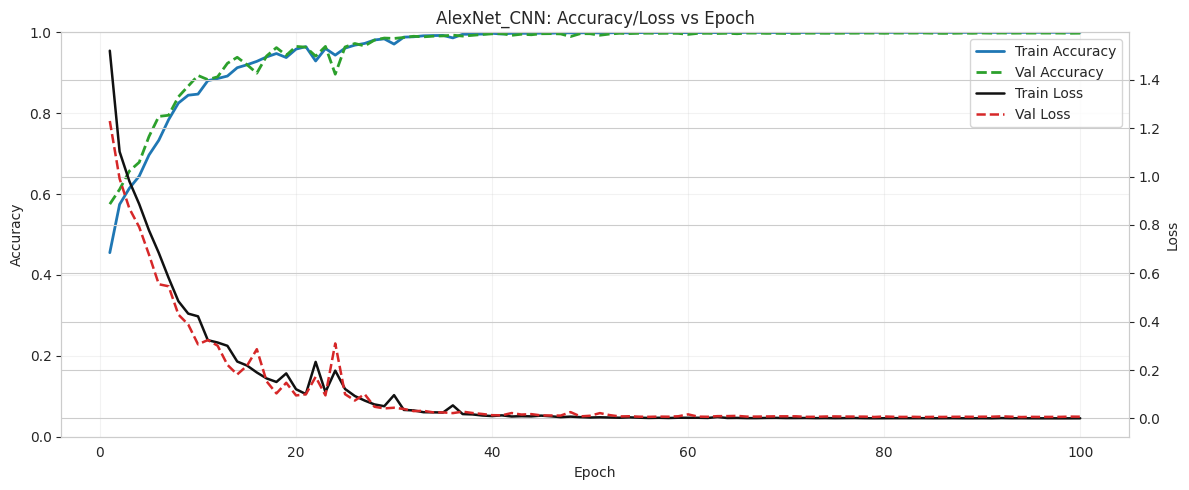

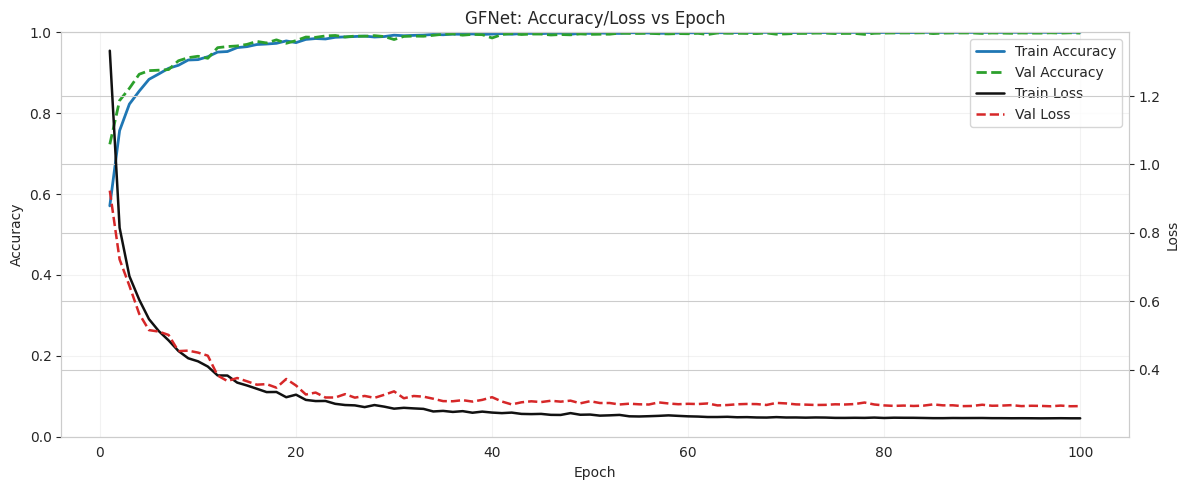

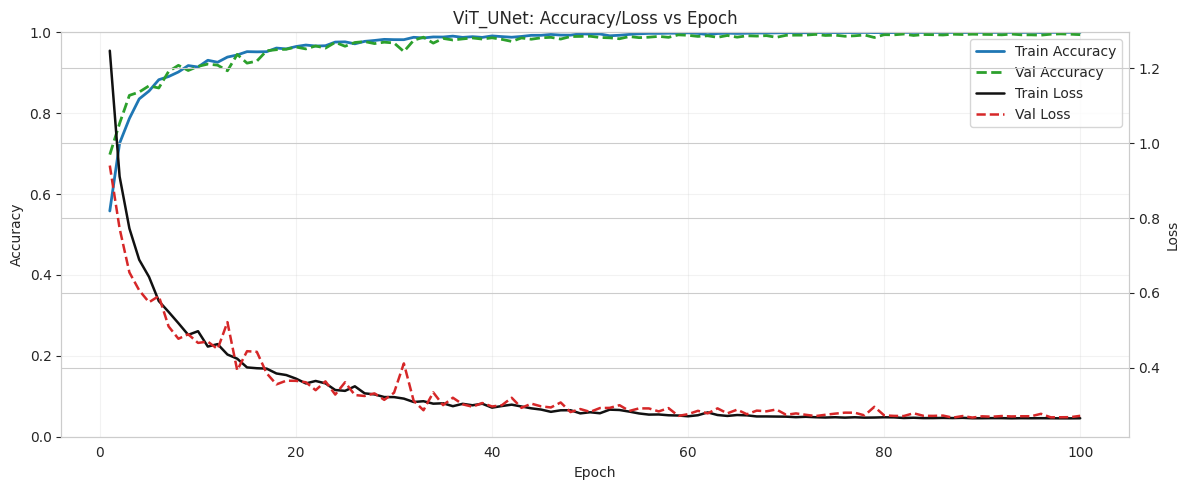

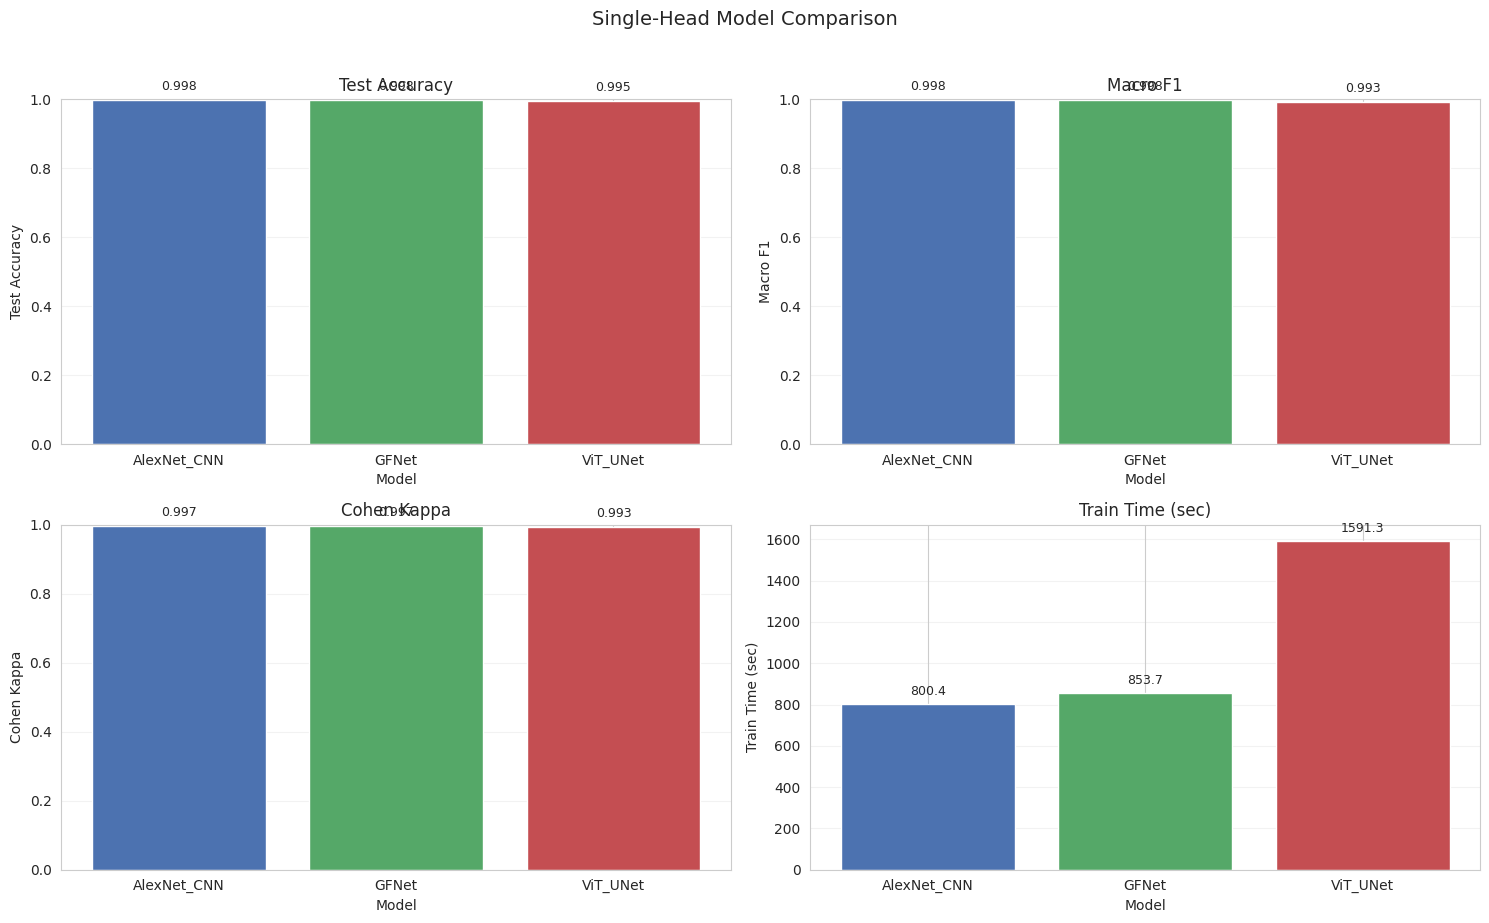

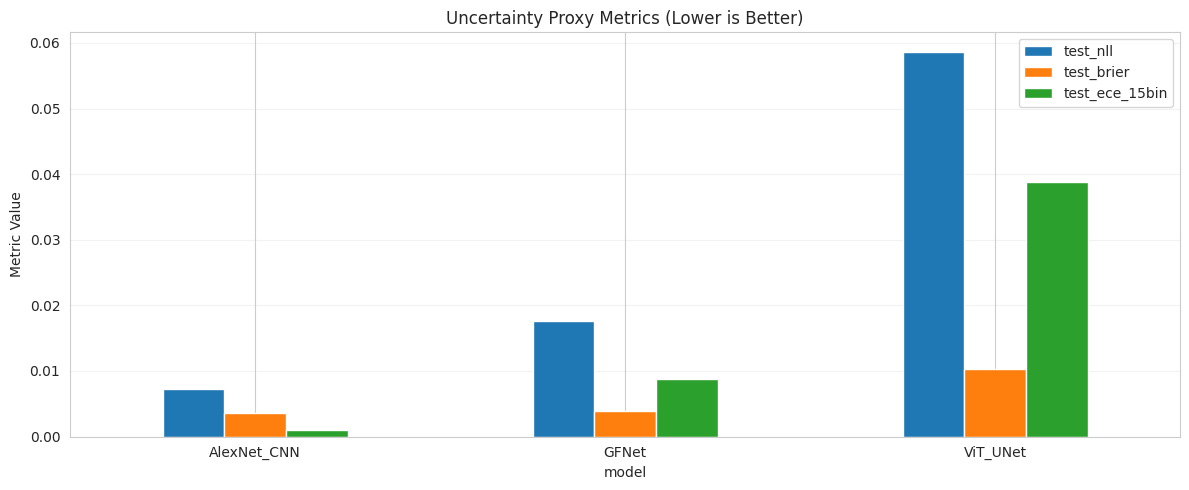

Saved training comparison plots to: /content/drive/My Drive/m_p/saved_models/training_plots


In [ ]:
# -----------------------------
# Training curves + compact cross-model comparison
# -----------------------------
for model_name, artifact in model_artifacts.items():
    hist = artifact["history"]
    epochs = np.arange(1, len(hist["loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(epochs, hist["accuracy"], color="#1f77b4", linewidth=2, label="Train Accuracy")
    ax1.plot(epochs, hist["val_accuracy"], color="#2ca02c", linewidth=2, linestyle="--", label="Val Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, alpha=0.25)

    ax2 = ax1.twinx()
    ax2.plot(epochs, hist["loss"], color="#111111", linewidth=1.8, label="Train Loss")
    ax2.plot(epochs, hist["val_loss"], color="#d62728", linewidth=1.8, linestyle="--", label="Val Loss")
    ax2.set_ylabel("Loss")

    lines = ax1.get_lines() + ax2.get_lines()
    labels = [ln.get_label() for ln in lines]
    ax1.legend(lines, labels, loc="upper right", frameon=True)
    plt.title(f"{model_name}: Accuracy/Loss vs Epoch")
    plt.tight_layout()

    curve_path = PLOT_DIR / f"{model_name}_training_curves.png"
    plt.savefig(curve_path, dpi=200, bbox_inches="tight")
    plt.show()


plot_df = summary_df[[
    "model",
    "test_accuracy",
    "macro_f1",
    "kappa",
    "train_time_sec",
    "test_nll",
    "test_brier",
    "test_ece_15bin",
]].copy()
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

metric_specs = [
    ("test_accuracy", "Test Accuracy", (0.0, 1.0), "{:.3f}"),
    ("macro_f1", "Macro F1", (0.0, 1.0), "{:.3f}"),
    ("kappa", "Cohen Kappa", (0.0, 1.0), "{:.3f}"),
    ("train_time_sec", "Train Time (sec)", None, "{:.1f}"),
]

palette = ["#4c72b0", "#55a868", "#c44e52"]
for ax, (col, title, ylim, fmt) in zip(axes, metric_specs):
    local = plot_df[["model", col]].copy()
    bars = ax.bar(local["model"], local[col], color=palette[: len(local)])
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.25)
    for patch in bars:
        height = patch.get_height()
        x = patch.get_x() + patch.get_width() / 2
        offset = (ylim[1] - ylim[0]) * 0.02 if ylim is not None else max(local[col].max() * 0.02, 0.05)
        ax.text(x, height + offset, fmt.format(height), ha="center", va="bottom", fontsize=9)

plt.suptitle("Single-Head Model Comparison", y=1.02, fontsize=14)
plt.tight_layout()
comparison_path = PLOT_DIR / "model_comparison_metrics.png"
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

# Calibration proxy chart for uncertainty readiness
fig, ax = plt.subplots(figsize=(12, 5))
calib_cols = ["test_nll", "test_brier", "test_ece_15bin"]
calib_df = plot_df[["model"] + calib_cols].set_index("model")
calib_df.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Uncertainty Proxy Metrics (Lower is Better)")
ax.set_ylabel("Metric Value")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
calib_path = PLOT_DIR / "uncertainty_proxy_metrics.png"
plt.savefig(calib_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved training comparison plots to:", PLOT_DIR)

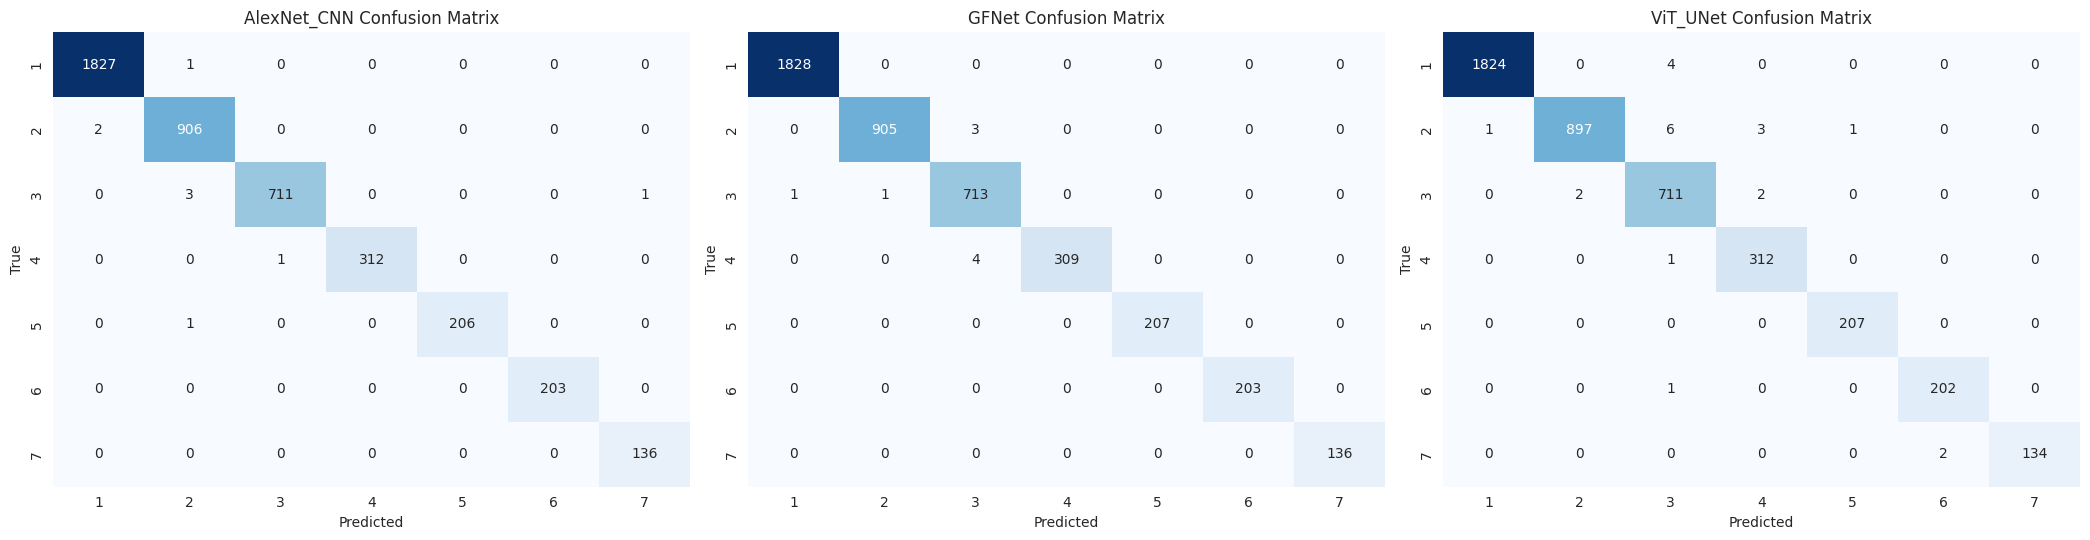

Saved confusion matrix figure: /content/drive/My Drive/m_p/saved_models/training_plots/confusion_matrices_side_by_side.png


In [ ]:
# -----------------------------
# Confusion matrices side-by-side
# -----------------------------
class_ticks = [str(i + 1) for i in range(num_classes)]
fig, axes = plt.subplots(1, len(model_artifacts), figsize=(7 * len(model_artifacts), 5.5))

if len(model_artifacts) == 1:
    axes = [axes]

for ax, (model_name, artifact) in zip(axes, model_artifacts.items()):
    sns.heatmap(
        artifact["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_ticks,
        yticklabels=class_ticks,
        cbar=False,
        ax=ax,
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
cm_path = PLOT_DIR / "confusion_matrices_side_by_side.png"
plt.savefig(cm_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved confusion matrix figure:", cm_path)

## Visualisation and Classification Image

In [11]:
# -----------------------------
# Optional: load saved model later
# -----------------------------
CUSTOM_OBJECTS = {
    "PatchExtractor": PatchExtractor,
    "PatchPositionEncoder": PatchPositionEncoder,
    "GlobalFilterLayer": GlobalFilterLayer,
    "PatchEncoderWithCLS": PatchEncoderWithCLS,
}

# Example:
example_path = MODEL_DIR / "ViT_UNet_final.keras"
if example_path.exists():
    loaded_model = keras.models.load_model(
        example_path,
        custom_objects=CUSTOM_OBJECTS,
        compile=False,
        safe_mode=False,
    )
    print("Loaded:", example_path)
    print("Model name:", loaded_model.name)
else:
    print("Example model not found yet. Train first, then reload.")

Loaded: /content/drive/My Drive/m_p/saved_models/ViT_UNet_final.keras
Model name: ViT_UNet_SingleHead


In [12]:
# -----------------------------
# Visualization save imports
# -----------------------------
import io
from matplotlib.colors import ListedColormap
from openpyxl import Workbook, load_workbook
from openpyxl.drawing.image import Image as XLImage


In [13]:
# -----------------------------
# Scene visualization helpers
# -----------------------------
VIS_DIR = MODEL_DIR / "scene_visualizations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

VIS_EXCEL_PATH = VIS_DIR / "initial_classification_maps.xlsx"

CLASS_COLOR_BASE = [
    "#0000FF",  # Blue
    "#00FF00",  # Green
    "#FF0000",  # Red
    "#00FFFF",  # Cyan
    "#FF00FF",  # Magenta
    "#FFFF00",  # Yellow
    "#A52A2A",  # Brown
    "#FFA500",
    "#7FFF00",
    "#8A2BE2",
]
BACKGROUND_COLOR = "#000000"


def get_scene_rgb(x_img, bands):
    if bands >= 6:
        rgb_idx = [bands // 2 - 1, bands // 2, bands // 2 + 1]
    elif bands >= 3:
        rgb_idx = [0, 1, 2]
    else:
        raise ValueError(f"Need at least 3 bands to form RGB, got {bands}.")
    return np.clip(x_img[:, :, rgb_idx], 0.0, 1.0)


def get_display_cmap(num_classes):
    return ListedColormap([BACKGROUND_COLOR] + CLASS_COLOR_BASE[:num_classes])


def predict_full_scene_labels(model, x_img, patch_size=9, batch_size=256):
    pad = patch_size // 2
    x_pad = np.pad(x_img, ((pad, pad), (pad, pad), (0, 0)), mode="edge")
    preds = np.zeros((x_img.shape[0], x_img.shape[1]), dtype=np.int32)

    for r in range(x_img.shape[0]):
        row_patches = np.empty(
            (x_img.shape[1], patch_size, patch_size, x_img.shape[-1]),
            dtype=np.float32,
        )
        for c in range(x_img.shape[1]):
            row_patches[c] = x_pad[r:r + patch_size, c:c + patch_size, :]

        row_prob = model.predict(row_patches, batch_size=batch_size, verbose=0)
        preds[r] = np.argmax(row_prob, axis=1) + 1  # back to 1..K

    return preds


def load_saved_models_for_visualization(model_dir, custom_objects):
    model_files = {
        "AlexNet_CNN": model_dir / "AlexNet_CNN_best.keras",
        "GFNet": model_dir / "GFNet_best.keras",
        "ViT_UNet": model_dir / "ViT_UNet_best.keras",
    }

    loaded = {}
    missing = {}

    for model_key, model_path in model_files.items():
        if not model_path.exists():
            missing[model_key] = f"Missing file: {model_path}"
            continue

        try:
            loaded[model_key] = keras.models.load_model(
                model_path,
                custom_objects=custom_objects,
                compile=False,
                safe_mode=False,
            )
        except Exception as exc:
            missing[model_key] = f"Load failed: {exc}"

    return loaded, missing


def save_single_panel(image, title, save_path, cmap=None, vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    if cmap is None:
        ax.imshow(image)
    else:
        ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    fig.tight_layout()
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", save_path)


def save_combined_overview(rgb_image, y_true, pred_maps, missing_info, num_classes, save_path):
    cmap = get_display_cmap(num_classes)

    panels = [
        ("Approximate RGB", rgb_image, "rgb"),
        ("True Label Map", y_true, "label"),
        ("AlexNet Initial Classification", pred_maps.get("AlexNet_CNN"), "label"),
        ("GFNet Initial Classification", pred_maps.get("GFNet"), "label"),
        ("ViT Initial Classification", pred_maps.get("ViT_UNet"), "label"),
    ]

    fig, axes = plt.subplots(1, len(panels), figsize=(30, 7), sharex=True, sharey=True)

    for ax, (title, img, kind) in zip(axes, panels):
        ax.set_title(title, fontsize=13)

        if kind == "rgb":
            ax.imshow(img)
        else:
            if img is None:
                ax.imshow(np.zeros_like(y_true), cmap=cmap, vmin=0, vmax=num_classes)
                key = None
                if "AlexNet" in title:
                    key = "AlexNet_CNN"
                elif "GFNet" in title:
                    key = "GFNet"
                elif "ViT" in title:
                    key = "ViT_UNet"
                ax.text(
                    0.5,
                    0.5,
                    missing_info.get(key, "Unavailable"),
                    ha="center",
                    va="center",
                    fontsize=10,
                    wrap=True,
                    transform=ax.transAxes,
                )
            else:
                ax.imshow(img, cmap=cmap, vmin=0, vmax=num_classes)

        ax.axis("off")

    handles = [plt.Rectangle((0, 0), 1, 1, color=BACKGROUND_COLOR, label="Background")]
    for i in range(num_classes):
        handles.append(
            plt.Rectangle((0, 0), 1, 1, color=CLASS_COLOR_BASE[i], label=f"Class {i+1}")
        )

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=min(num_classes + 1, 8),
        bbox_to_anchor=(0.5, -0.02),
        frameon=True,
    )
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Saved:", save_path)


def save_images_to_excel(excel_path, image_paths, sheet_name="Initial_Classification_Maps"):
    if excel_path.exists():
        wb = load_workbook(excel_path)
        if sheet_name in wb.sheetnames:
            del wb[sheet_name]
        ws = wb.create_sheet(title=sheet_name)
    else:
        wb = Workbook()
        ws = wb.active
        ws.title = sheet_name

    anchors = ["A1", "J1", "A25", "J25", "A49", "J49"]
    for path, anchor in zip(image_paths, anchors):
        if path.exists():
            img = XLImage(str(path))
            img.anchor = anchor
            ws.add_image(img)

    wb.save(excel_path)
    print("Saved Excel workbook:", excel_path)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'gf_patch_encoder', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Generating full-scene classified image for AlexNet_CNN...
AlexNet_CNN map shape: (330, 307)
Generating full-scene classified image for GFNet...
GFNet map shape: (330, 307)
Generating full-scene classified image for ViT_UNet...
ViT_UNet map shape: (330, 307)


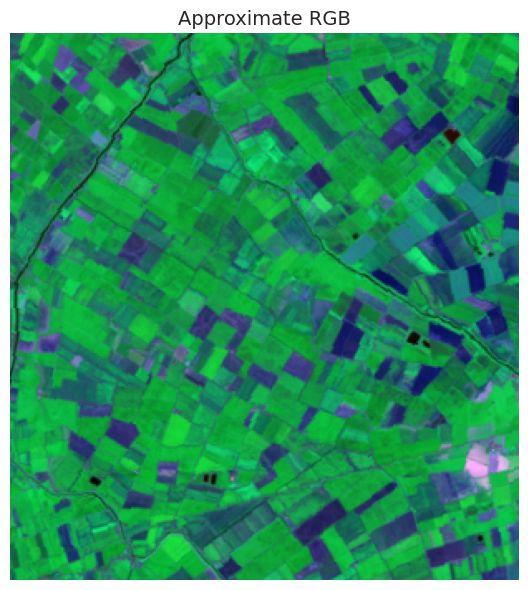

Saved: /content/drive/My Drive/m_p/saved_models/scene_visualizations/scene_rgb.png


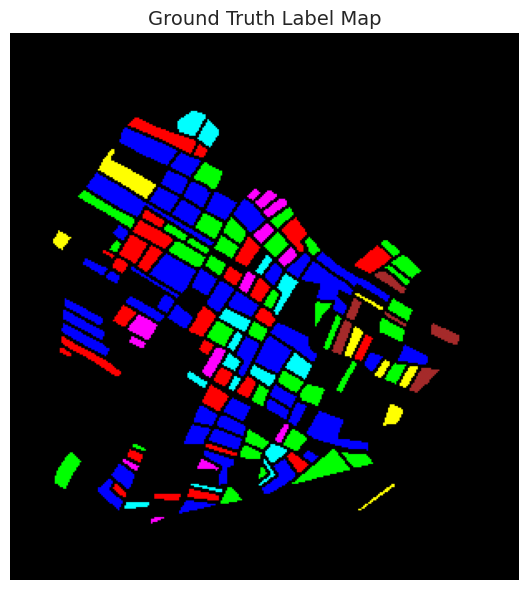

Saved: /content/drive/My Drive/m_p/saved_models/scene_visualizations/ground_truth_label_map.png


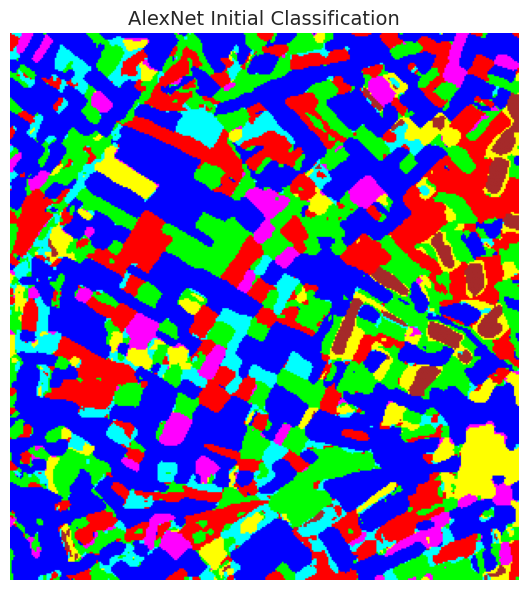

Saved: /content/drive/My Drive/m_p/saved_models/scene_visualizations/AlexNet_CNN_initial_classification.png


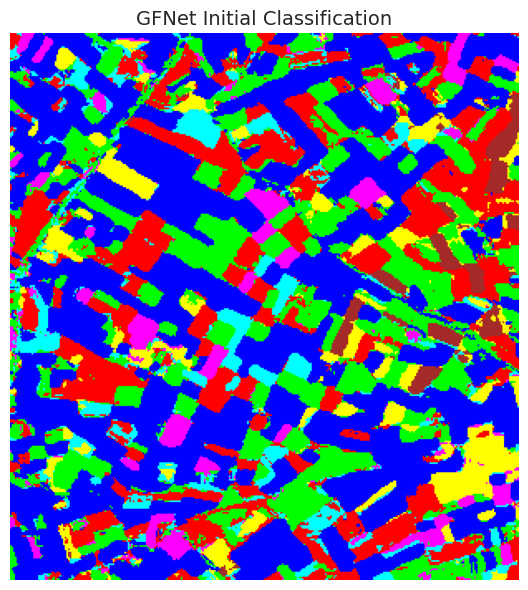

Saved: /content/drive/My Drive/m_p/saved_models/scene_visualizations/GFNet_initial_classification.png


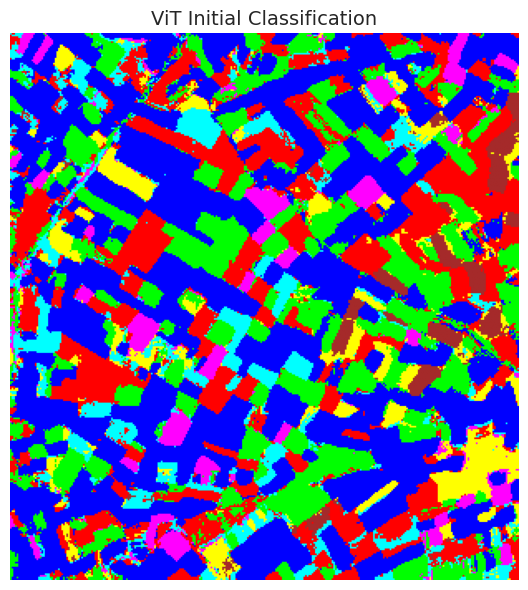

Saved: /content/drive/My Drive/m_p/saved_models/scene_visualizations/ViT_UNet_initial_classification.png


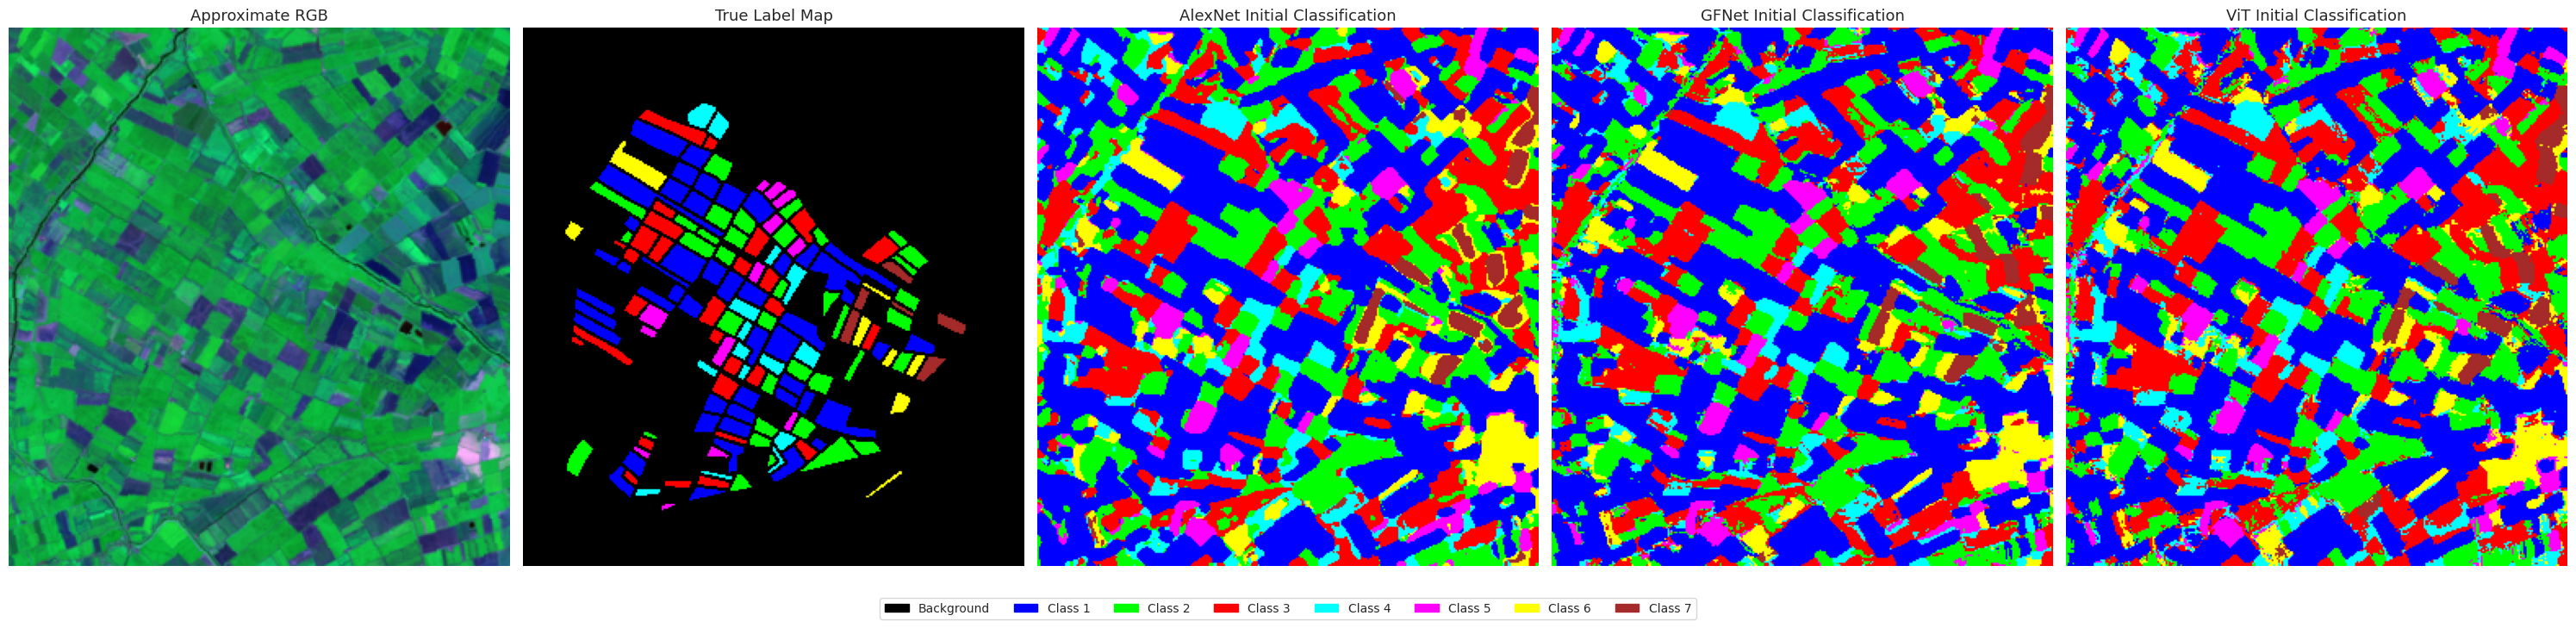

Saved: /content/drive/My Drive/m_p/saved_models/scene_visualizations/combined_initial_classification_overview.png
Saved Excel workbook: /content/drive/My Drive/m_p/saved_models/scene_visualizations/initial_classification_maps.xlsx
All visualization outputs saved in: /content/drive/My Drive/m_p/saved_models/scene_visualizations


In [14]:
# -----------------------------
# Load saved models, generate maps, save PNGs and Excel
# -----------------------------
VIS_CUSTOM_OBJECTS = {
    "PatchExtractor": PatchExtractor,
    "PatchPositionEncoder": PatchPositionEncoder,
    "GlobalFilterLayer": GlobalFilterLayer,
    "PatchEncoderWithCLS": PatchEncoderWithCLS,
}

scene_rgb = get_scene_rgb(x_img, B)
display_cmap = get_display_cmap(num_classes)

loaded_models, missing_models = load_saved_models_for_visualization(MODEL_DIR, VIS_CUSTOM_OBJECTS)
prediction_maps = {}

for model_key, loaded_model in loaded_models.items():
    print(f"Generating full-scene classified image for {model_key}...")
    prediction_maps[model_key] = predict_full_scene_labels(
        loaded_model,
        x_img,
        patch_size=PATCH_SIZE,
        batch_size=BATCH_SIZE,
    )
    print(f"{model_key} map shape:", prediction_maps[model_key].shape)

if missing_models:
    print("Some models could not be loaded:")
    for model_key, reason in missing_models.items():
        print(f" - {model_key}: {reason}")

# Save individual PNGs
rgb_png = VIS_DIR / "scene_rgb.png"
gt_png = VIS_DIR / "ground_truth_label_map.png"
alex_png = VIS_DIR / "AlexNet_CNN_initial_classification.png"
gfnet_png = VIS_DIR / "GFNet_initial_classification.png"
vit_png = VIS_DIR / "ViT_UNet_initial_classification.png"
overview_png = VIS_DIR / "combined_initial_classification_overview.png"

save_single_panel(scene_rgb, "Approximate RGB", rgb_png)
save_single_panel(y_img, "Ground Truth Label Map", gt_png, cmap=display_cmap, vmin=0, vmax=num_classes)

if prediction_maps.get("AlexNet_CNN") is not None:
    save_single_panel(
        prediction_maps["AlexNet_CNN"],
        "AlexNet Initial Classification",
        alex_png,
        cmap=display_cmap,
        vmin=0,
        vmax=num_classes,
    )

if prediction_maps.get("GFNet") is not None:
    save_single_panel(
        prediction_maps["GFNet"],
        "GFNet Initial Classification",
        gfnet_png,
        cmap=display_cmap,
        vmin=0,
        vmax=num_classes,
    )

if prediction_maps.get("ViT_UNet") is not None:
    save_single_panel(
        prediction_maps["ViT_UNet"],
        "ViT Initial Classification",
        vit_png,
        cmap=display_cmap,
        vmin=0,
        vmax=num_classes,
    )

# Save combined overview PNG
save_combined_overview(
    rgb_image=scene_rgb,
    y_true=y_img,
    pred_maps=prediction_maps,
    missing_info=missing_models,
    num_classes=num_classes,
    save_path=overview_png,
)

# Save PNGs into Excel workbook
image_paths_for_excel = [rgb_png, gt_png, alex_png, gfnet_png, vit_png, overview_png]
save_images_to_excel(VIS_EXCEL_PATH, image_paths_for_excel, sheet_name="Initial_Classification_Maps")

print("All visualization outputs saved in:", VIS_DIR)
